<a href="https://colab.research.google.com/github/guspus101-art/CV_lab/blob/main/CV_lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_4645/4213001138.py:30: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(original.ravel(),256,[0,256],color='black')
/tmp/ipykernel_4645/4213001138.py:42: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(equalized.ravel(),256,[0,256],color='black')


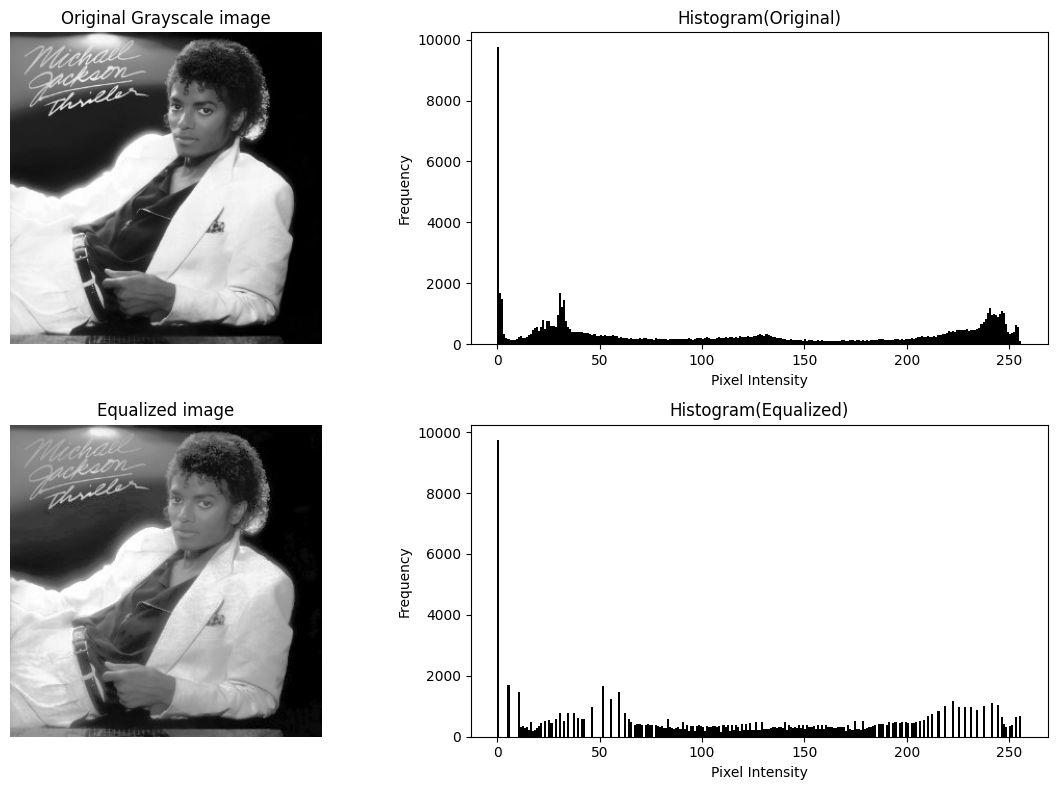

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
def custom_equalize_hist(img):
  hist,_=np.histogram(img.flatten(),bins=256,range=[0,256])
  cdf=hist.cumsum()
  cdf_nonzero=cdf[cdf>0]
  cdf_min=cdf_nonzero[0] if len(cdf_nonzero)>0 else 0
  total_pixels=img.size
  L=256
  numerator=(cdf-cdf_min)*(L-1)
  denominator=(total_pixels)-cdf_min
  if denominator==0:
    cdf_normalized=np.zeros_like(cdf)
  else:
    cdf_normalized=np.round(numerator/denominator)
    cdf_normalized=cdf_normalized.astype('uint8')
    return cdf_normalized[img]
def show_comparison(original,equalized):
  plt.figure(figsize=(12,8))

  #1. Original img
  plt.subplot(2,2,1)
  plt.imshow(original,cmap='gray')
  plt.title('Original Grayscale image')
  plt.axis('off')

  #2. Histogram of Original image
  plt.subplot(2,2,2)
  plt.hist(original.ravel(),256,[0,256],color='black')
  plt.title("Histogram(Original)")
  plt.xlabel('Pixel Intensity')
  plt.ylabel('Frequency')
  #3. Equalized Image
  plt.subplot(2,2,3)
  plt.imshow(equalized,cmap='gray')
  plt.title('Equalized image')
  plt.axis('off')

  #4. Histogram of Equalized image
  plt.subplot(2,2,4)
  plt.hist(equalized.ravel(),256,[0,256],color='black')
  plt.title("Histogram(Equalized)")
  plt.xlabel('Pixel Intensity')
  plt.ylabel('Frequency')
  plt.tight_layout()
  plt.show()
#load the image in greyscale
img=cv2.imread("/content/drive/MyDrive/Michael_Jackson_-_Thriller.png",0)
#check if image is loaded properly
if img is None:
  print("Error: Image not found")
else:
  #Apply Histogram equalization
  equ=custom_equalize_hist(img)
  #show the comparison
  show_comparison(img,equ)
